## Business Understanding
#### **SyriaTel**, a leading telecommunications provider, is seeking a predictive solution to help reduce customer churn. The company has tasked me with developing a model that can accurately forecast whether a customer is likely to stay with the service or leave. By identifying patterns in customer behavior, this model will enable SyriaTel to take proactive measures to retain valuable customers and minimize revenue loss due to churn.


## Project Objectives
### This project seeks to achieve the following goals:

#### 1. Identify the most effective model for accurately predicting customer churn.

#### 2. Determine the key features that significantly influence a customer’s decision to remain with or leave SyriaTel.


In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns

In [2]:
# load the dataset
telecomdf1 = pd.read_csv(r"C:\Users\vivia\Downloads\Phase_3_project\Telecondata.csv")

#### The 'churn' column serves as our target variable.
#### It indicates whether a customer is still with the company ("No") 
#### or has left ("Yes"), making it a binary classification feature.


### Data Cleaning

In [3]:
# Remove the white noise in the column names. Replace space with underscore
telecomdf1.columns = telecomdf1.columns.str.replace(" ", "_")
telecomdf1.columns

Index(['state', 'account_length', 'area_code', 'phone_number',
       'international_plan', 'voice_mail_plan', 'number_vmail_messages',
       'total_day_minutes', 'total_day_calls', 'total_day_charge',
       'total_eve_minutes', 'total_eve_calls', 'total_eve_charge',
       'total_night_minutes', 'total_night_calls', 'total_night_charge',
       'total_intl_minutes', 'total_intl_calls', 'total_intl_charge',
       'customer_service_calls', 'churn'],
      dtype='object')

In [4]:
# ensure all the values in the churn column are in lowercase and all white spaces are removed within the values in that column
telecomdf1['churn'] = telecomdf1['churn'].astype(str).str.strip().str.lower()

In [5]:
# Label encode where "yes = 1" and "No = 0". Done to enable us train the models
telecomdf1["churn"] = telecomdf1["churn"].map({"false": 0, "true": 1})
telecomdf1["churn"].unique()


array([0, 1])

In [6]:
# look for missing values in all the columns
telecomdf1.isna().sum()

state                     0
account_length            0
area_code                 0
phone_number              0
international_plan        0
voice_mail_plan           0
number_vmail_messages     0
total_day_minutes         0
total_day_calls           0
total_day_charge          0
total_eve_minutes         0
total_eve_calls           0
total_eve_charge          0
total_night_minutes       0
total_night_calls         0
total_night_charge        0
total_intl_minutes        0
total_intl_calls          0
total_intl_charge         0
customer_service_calls    0
churn                     0
dtype: int64

In [7]:
# checking for duplicate values
telecomdf1.duplicated().sum()

np.int64(0)

In [8]:
# select only numerical columns
telecomdf1 = telecomdf1.select_dtypes(include = "number")

## MODEL 1:LOGISTIC REGRESSION

### step 1: split the dataset into train and test

In [9]:
# make a copy of the dataset
telecomdf = telecomdf1.copy()
telecomdf.head(3)

,account_length,area_code,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0


In [10]:
# seperate the dataset into train and test dataset
X = telecomdf.drop(columns = "churn")
y = telecomdf["churn"]
# Split the data into train and test dataset
x1_train, x1_test, y1_train, y1_test = train_test_split(X, y, test_size = 0.25, random_state = 42)
y1_train.value_counts() 

churn
0    2141
1     358
Name: count, dtype: int64

### Step 2: Train and use the model to make prediction

In [11]:
# instantiate the model
Lr = LogisticRegression(random_state = 42)

In [12]:
# Instantiate the model
Lr = LogisticRegression(max_iter = 1000, random_state = 42)
# fit the model
Lr.fit(x1_train, y1_train)

# make prediction 
y_pred1 = Lr.predict(x1_test)


### Step 3: Evaluate the model using the classification metrics

In [13]:
# Evaluate the model performance using precision, F1 -Score, Accuracy and AUC 
accuracy = accuracy_score(y1_test, y_pred1)*100
precision = precision_score(y1_test, y_pred1)*100
recall = recall_score(y1_test, y_pred1)*100
auc = roc_auc_score(y1_test, y_pred1)*100

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"AUC: {auc:.2f}")

Accuracy: 85.73
Precision: 66.67
Recall: 9.60
AUC: 54.38


### Step 3: Perform feature engineering, correct multicollinearity, preprocessing (standardization) and correct class imbalance to try improve the model performance

In [14]:
# Create a copy of the original dataset
telecomdf2 = telecomdf1.copy()

#### Feature ingeneering

In [15]:
# Combine  the total day, night and evening charge into one column
# Combine  the total day, night and evening minutes into one column
# Combine  the total day, night and evening calls into one column
telecomdf2["total_daily_charge"] = telecomdf2["total_day_charge"]+ telecomdf2["total_eve_charge"] + telecomdf2["total_night_charge"]
telecomdf2["total_daily_minutes"] = telecomdf2["total_day_minutes"]+ telecomdf2["total_eve_minutes"] + telecomdf2["total_night_minutes"]
telecomdf2["total_daily_calls"] = telecomdf2["total_eve_calls"]+ telecomdf2["total_night_calls"] + telecomdf2["total_day_calls"]

In [16]:
# delete columns that have been used in the above cell to feature engineer as well as account _length and Area_code which cannot be used to predict the  mode
del telecomdf2["total_day_charge"]
del telecomdf2["total_day_calls"]
del telecomdf2["total_day_minutes"]
del telecomdf2["total_eve_charge"]
del telecomdf2["total_eve_calls"]
del telecomdf2["total_eve_minutes"]
del telecomdf2["total_night_charge"]
del telecomdf2["total_night_calls"]
del telecomdf2["total_night_minutes"]
del telecomdf2["account_length"]
del telecomdf2["area_code"]

In [17]:
# drop the non-numerical values
telecomdf2 = telecomdf2.select_dtypes(include = ["number"])

In [18]:
# check for multicollinearity btn the independent variables excluding the label = churn. We check  for features that have a correlation greater than 0.8
# Select only feature columns
features = telecomdf2.drop(columns=['churn'])

# Compute absolute correlation matrix
corr_matrix = features.corr().abs()

# Keep only upper triangle (to avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find feature pairs with correlation > 0.8
high_corr = [(column, row, upper.loc[row, column]) 
             for column in upper.columns 
             for row in upper.index 
             if upper.loc[row, column] > 0.8]

print("Highly correlated feature pairs (|corr| > 0.8):")
for pair in high_corr:
    print(pair)

Highly correlated feature pairs (|corr| > 0.8):
('total_intl_charge', 'total_intl_minutes', np.float64(0.9999927417510314))
('total_daily_minutes', 'total_daily_charge', np.float64(0.8916739057231682))


In [19]:
# Drop one of each pair that has high correlation
del telecomdf2["total_intl_minutes"]
del telecomdf2["total_daily_minutes"]

In [20]:
# make a copy of the above transformed dataset since we will use it in the decision tree
telecomdf_new = telecomdf2.copy()

#### Feature Scaling: standardization - Used since we are not sure about the distribution of the features

In [21]:
# instantiate the StandardScaler
scaler = StandardScaler()
# features to standardize
cols_to_scale = ['number_vmail_messages', 'total_intl_calls', 'total_intl_charge',
                 'customer_service_calls', 'total_daily_charge', 'total_daily_calls']

# Fit and transform the selected columns, then save back to DataFrame
telecomdf2[cols_to_scale] = scaler.fit_transform(telecomdf2[cols_to_scale])

#### Class imbalance: used SMOTE

In [22]:
## Check for class imbalance on the target variable (churn)
valueCount = telecomdf2["churn"].value_counts(normalize = True) * 100
valueCount 
## from the output below, we note that there are 85.50% Nos and 14.49% yes. This shows high imbalance which can lead to model being biased.
## To sort this out, we need to implement SMOTE Method after splitting the dataset into train and test dataset

churn
0    85.508551
1    14.491449
Name: proportion, dtype: float64

### Step 4: Train and use the model to make prediction

In [23]:
# separate the x and y values
X = telecomdf2.drop(columns = ["churn"])
y = telecomdf2["churn"]

# Split the data into trainng and testing dataset
x2_train, x2_test, y2_train, y2_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

# verify whether the class imbalance still stands on the train dataset
imbalance = y2_train.value_counts(normalize = True) * 100
imbalance
# from the output below, we noted that we have class imbalance still remains the same even for the target train dataset

churn
0    85.67427
1    14.32573
Name: proportion, dtype: float64

### Step 5: Class imbalance - SMOTE

In [24]:
# Therefore, we need to use the SMOTE method to rectify the class imbalance on the train dataset
# instantiate the SMOTE
sm = SMOTE(random_state = 42)

# perform the SMOTE on the train dataset
xsmote2_train, ysmote2_train = sm.fit_resample(x2_train, y2_train)

# instantiate the logistic regression model
Lr2 = LogisticRegression(solver = "lbfgs", max_iter = 1000)

# Train the linear regression model using the above resampled values
Lr2.fit(xsmote2_train, ysmote2_train)

# Using the trained model above, predict the y test
y2_pred = Lr2.predict(x2_test)





### Step 6: Test the model performance

In [25]:
# Test the model performance
accuracy = accuracy_score(y2_test, y2_pred)*100
precision = precision_score(y2_test, y2_pred)*100
recall = recall_score(y2_test, y2_pred)*100
auc = roc_auc_score(y2_test, y2_pred)*100

print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"AUC: {auc:.2f}%")

Accuracy: 71.82%
Precision: 31.54%
Recall: 75.20%
AUC: 73.21%


## Logistic Regression Conclusion: Model Performance Summary

#### The initial logistic regression model achieved an accuracy of 85.7%, but its recall (9.6%) and AUC (0.54) were very low. This indicates that, although the model correctly predicted most non-churn cases, it failed to identify the majority of actual churners — making it ineffective for churn prediction.

#### After making changes to the dataset, the updated model’s accuracy decreased to 71.8%, but recall improved significantly to 75.2% and AUC increased to 0.73. This shows that the model is now much better at distinguishing between churners and non-churners, even though it makes more false positive predictions (as seen from the lower precision of 0.32).

#### Overall, the second model performs better because it achieves a stronger balance between correctly identifying churners and overall classification ability

## MODEL 2: DECISION TREE

### Step 1: Make a copy of the dataset

In [26]:
## Make a copy of the original dataset
telecomdf3 = telecomdf_new.copy()
telecomdf3.head()

,number_vmail_messages,total_intl_calls,total_intl_charge,customer_service_calls,churn,total_daily_charge,total_daily_calls
0,25,3,2.70,1,0,72.86,300
1,26,3,3.70,1,0,55.54,329
2,0,5,3.29,0,0,59.00,328
3,0,7,1.78,2,0,65.02,248
4,0,3,2.73,3,0,49.36,356


### Step 2: Train and use the model to make prediction

In [27]:
# specify both the y and x values
X = telecomdf3.drop(columns = ["churn"])
y = telecomdf3["churn"]

# split the data into train and split dataset
x3_train, x3_test, y3_train, y3_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

# Instantiate the decision tree and include class_weight to balance the 
tree = DecisionTreeClassifier(class_weight='balanced', random_state = 42)

# train the model
tree.fit(x3_train, y3_train)

# Predict the model
y3_pred = tree.predict(x3_test)

### Step 3: Model Performance

In [28]:
# Test the model performance
accuracy = accuracy_score(y3_test, y3_pred)*100
precision = precision_score(y3_test, y3_pred)*100
recall = recall_score(y3_test, y3_pred)*100
auc = roc_auc_score(y3_test, y3_pred)*100

print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"AUC: {auc:.2f}%")

Accuracy: 91.85%
Precision: 72.44%
Recall: 73.60%
AUC: 84.33%


### Step 4: Check for overfitting and Underfitting

In [29]:
train_acc = tree.score(x3_train, y3_train)*100
test_acc = tree.score(x3_test, y3_test)*100

if train_acc > test_acc:
    print(f"overfitting: train_acc:{train_acc:.2f}% and test_acc:{test_acc: .2f}%")
elif train_acc < test_acc:
    print(f"underfitting: train_acc:{train_acc:.2}% and test_acc:{test_acc:.2f}%")


# The difference train_acc and test_acc 0.08 which is 8%. We will use the general rule of thumb i.e.
# Small gap (~0–5%) → Usually fine
# Moderate gap (~5–15%) → Some overfitting
# Large gap → (>15–20%)


overfitting: train_acc:100.00% and test_acc: 91.85%


In [30]:
# To correct the overfitting we will include the following parameters when instantiating the DecisionTreeClassifier
tree = DecisionTreeClassifier(
    class_weight='balanced',  # handles class imbalance
    max_depth=5,              # limits overfitting
    min_samples_split=10,     
    min_samples_leaf=5,
    random_state=42
)

# train the model
tree.fit(x3_train, y3_train)

# Predict the model
y3_pred = tree.predict(x3_test)

### Step 5: Test model performance after rectifying overfitting

In [31]:
# Test the model performance
accuracy = accuracy_score(y3_test, y3_pred)*100
precision = precision_score(y3_test, y3_pred)*100
recall = recall_score(y3_test, y3_pred)*100
auc = roc_auc_score(y3_test, y3_pred)*100

print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"AUC: {auc:.2f}%")

Accuracy: 86.69%
Precision: 53.85%
Recall: 78.40%
AUC: 83.28%


In [32]:
# evaluate whether overfitting has reduced
train_acc1 = tree.score(x3_train, y3_train)
test_acc1 = tree.score(x3_test, y3_test)

if train_acc > test_acc:
    print(f"overfitting: train_acc:{train_acc1:.2f} and test_acc:{test_acc1:.2f}")
elif train_acc < test_acc:
    print(f"underfitting: train_acc:{train_acc1:.2f} and test_acc:{test_acc1:.2f}")

# We note that the difference between train_acc1 and train_acc2 has reduced to 2% which is okay

overfitting: train_acc:0.88 and test_acc:0.87


In [33]:
telecomdf3.columns

Index(['number_vmail_messages', 'total_intl_calls', 'total_intl_charge',
       'customer_service_calls', 'churn', 'total_daily_charge',
       'total_daily_calls'],
      dtype='object')

### Plot an AUC curve to compare Logistic Regression and Decision Tree 


In [34]:
# Compute the AUC probabilities

# Decision Tree
tree_prob = tree.predict_proba(x3_test)[:, 1]
#Logistic Regression - second model
Log2_prob = Lr2.predict_proba(x2_test)[:, 1]

#### Compute the ROC Curve coordinates
log_fpr2, log_tpr2, _ = roc_curve(y2_test, Log2_prob)
tree_fpr, tree_tpr, _ = roc_curve(y3_test, tree_prob)

# Manually assign the known AUC scores (converted to decimal form)
log1_auc = 0.5438   # Logistic Regression - first model (54.38%)
log2_auc = 0.7321   # Logistic Regression - second model (73.21%)
tree_auc = 0.8328   # Decision Tree (83.28%)


### plot the ROC Curve

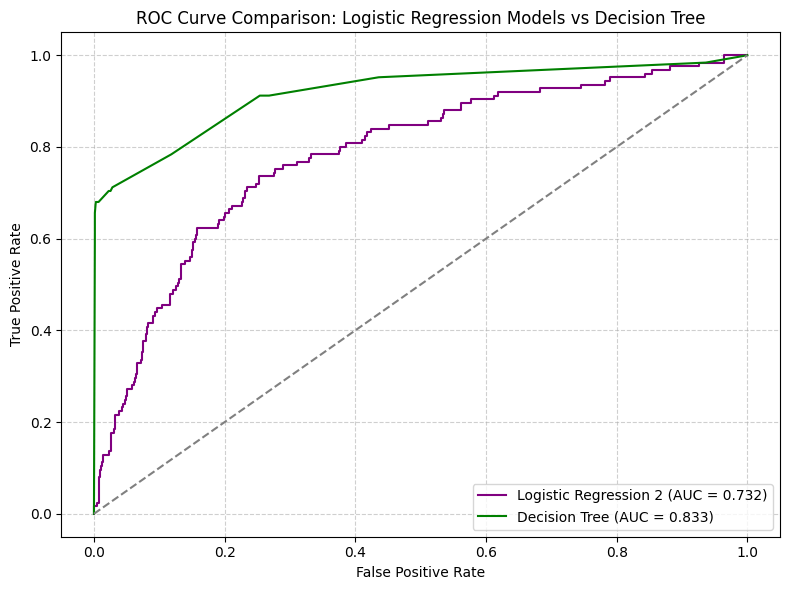

In [35]:
# Plot ROC curves together
plt.figure(figsize=(8,6))

# Plot each model's ROC curve with the correct AUC values
# plt.plot(log_fpr1, log_tpr1, color='blue', 
 #         label=f'Logistic Regression 1 (AUC = {log1_auc:.3f})')

plt.plot(log_fpr2, log_tpr2, color='purple', 
         label=f'Logistic Regression 2 (AUC = {log2_auc:.3f})')

plt.plot(tree_fpr, tree_tpr, color='green', 
         label=f'Decision Tree (AUC = {tree_auc:.3f})')

# Plot the 45-degree reference line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Add labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Logistic Regression Models vs Decision Tree')
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### **Model Selection**
### Based on the ROC curve above, decision tree is the best model since it has the hightest AUC Since it is the highest, we are going to perform feature importance


In [36]:
#get the feature coefficents
importance = tree.feature_importances_
# get the feature names
feature_names = X.columns

# Create a DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort by importance (highest first)
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
4,total_daily_charge,0.434382
3,customer_service_calls,0.295082
2,total_intl_charge,0.096500
1,total_intl_calls,0.083469
0,number_vmail_messages,0.056215
5,total_daily_calls,0.034352


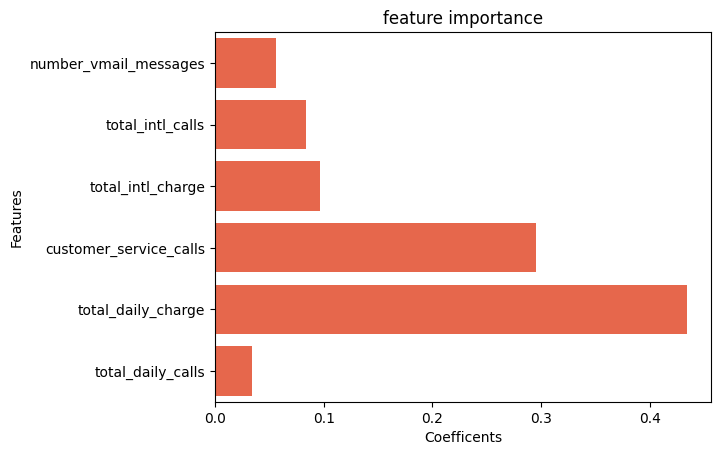

In [39]:
## plot a graph to show the feature importance
sns.barplot(y = feature_names, x = importance, color = "#FF5733")
plt.title("feature importance")
plt.xlabel("Coefficents")
plt.ylabel ("Features");

### **Feature Importance Summary**

### The analysis shows that total_daily_charge is the most important predictor of customer churn, followed by customer_service_calls. This indicates that customers with higher daily charges or frequent service calls are more likely to leave the company. Other variables such as total_intl_charge, total_intl_calls, and number_vmail_messages contribute moderately, while total_daily_calls has minimal impact. Overall, spending behavior and customer service interactions are the strongest indicators of churn